In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
os.listdir("../Nkhoma_data")

['Inpatient list Surgery',
 'Poor Patient Funds',
 'Data',
 'Volunteer Agreement',
 'ICU_research.xlsx',
 'laparoscopy_analysed.xlsx']

In [3]:
df = pd.read_excel("../Nkhoma_data/laparoscopy_analysed.xlsx")

/home/mat2m10/.pyenv/versions/3.12.9/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [4]:
# Assign placeholder IDs to rows missing a Hospital Number
mask = df["Hospital Number"].isna()
df.loc[mask, "Hospital Number"] = [f"UNKNOWN_{i+1}" for i in range(mask.sum())]

df = df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")])
df = df.reset_index(drop=True)

# Reset index
df = df.dropna(subset=["Name"])

# Age

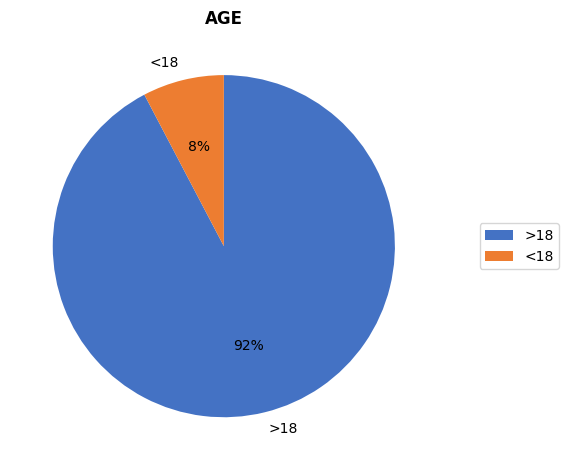

In [5]:
import matplotlib.pyplot as plt

age_groups = df["Age at surgery"].apply(lambda x: "<18" if x < 18 else ">18")
counts = age_groups.value_counts()

fig, ax = plt.subplots()
ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=["#4472C4", "#ED7D31"],  # blue for >18, orange for <18
    startangle=90,
    counterclock=False
)
ax.set_title("AGE", fontweight="bold")
ax.legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

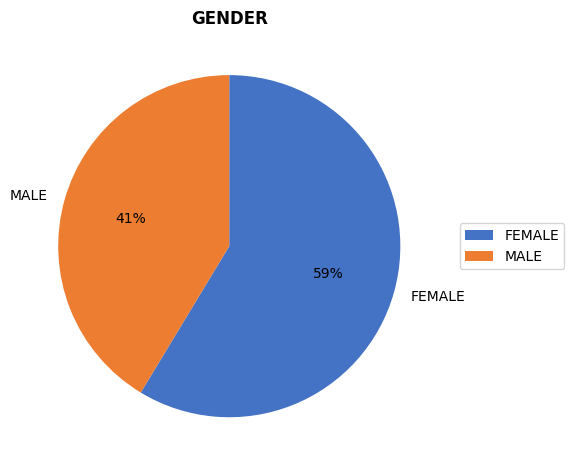

In [6]:
counts = df["Sex"].value_counts()

fig, ax = plt.subplots()
ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=["#4472C4", "#ED7D31"],  # blue for MALE, orange for FEMALE
    startangle=90,
    counterclock=False
)
ax.set_title("GENDER", fontweight="bold")
ax.legend(counts.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

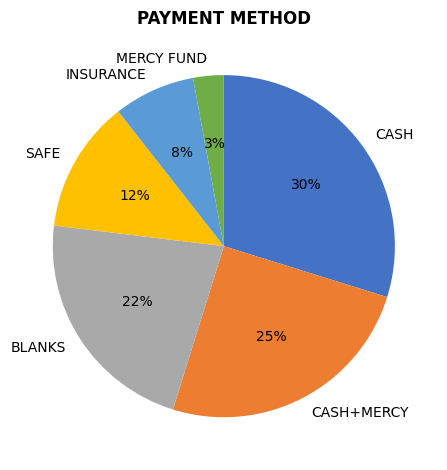

In [7]:
df["Payment Method (Scheme/ Cash)"] = df["Payment Method (Scheme/ Cash)"].str.strip().replace("", float("nan"))

counts = df["Payment Method (Scheme/ Cash)"].value_counts(dropna=False)
counts.index = counts.index.fillna("BLANKS")

colors = ["#4472C4", "#ED7D31", "#A9A9A9", "#FFC000", "#5B9BD5", "#70AD47"]

fig, ax = plt.subplots()
ax.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=colors,
    startangle=90,
    counterclock=False
)
ax.set_title("PAYMENT METHOD", fontweight="bold")
plt.tight_layout()
plt.show()

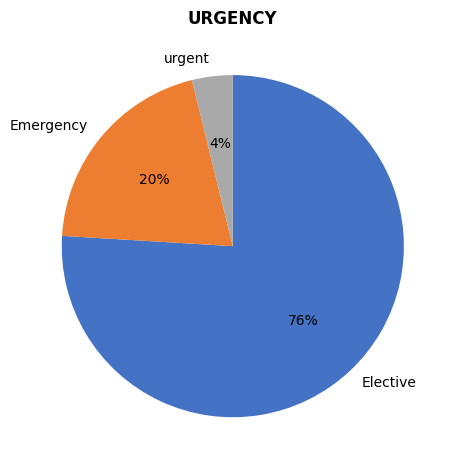

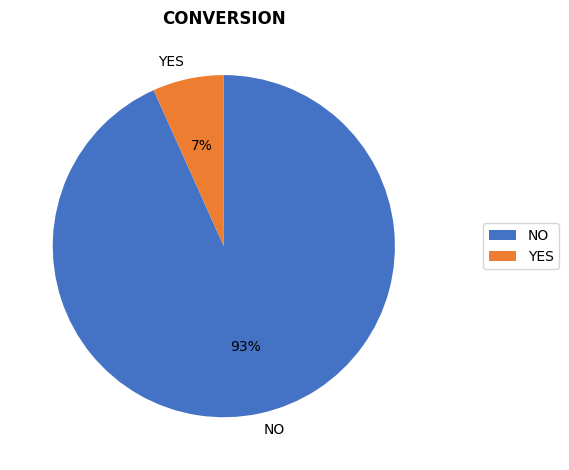

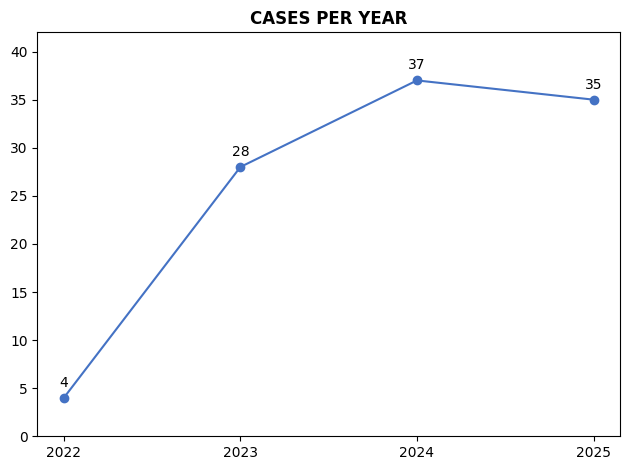

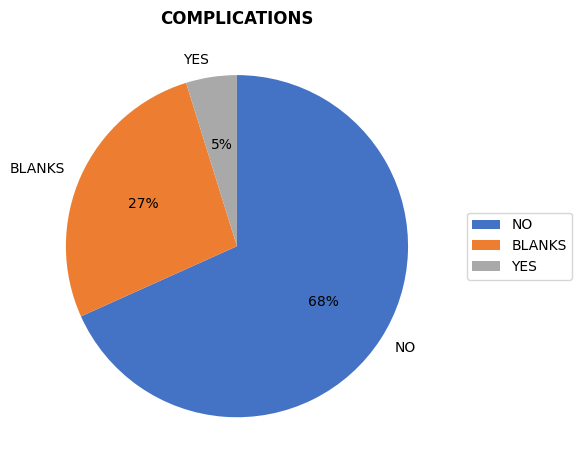

In [8]:
# --- URGENCY ---
counts_urgency = df["Urgency"].value_counts(dropna=False)
fig, ax = plt.subplots()
ax.pie(counts_urgency, labels=counts_urgency.index, autopct="%1.0f%%",
       colors=["#4472C4", "#ED7D31", "#A9A9A9"], startangle=90, counterclock=False)
ax.set_title("URGENCY", fontweight="bold")
plt.tight_layout()
plt.show()

# --- CONVERSION ---
counts_conv = df["Conversion"].str.strip().str.upper().value_counts(dropna=False)
counts_conv.index = counts_conv.index.fillna("BLANKS")
fig, ax = plt.subplots()
ax.pie(counts_conv, labels=counts_conv.index, autopct="%1.0f%%",
       colors=["#4472C4", "#ED7D31"], startangle=90, counterclock=False)
ax.set_title("CONVERSION", fontweight="bold")
ax.legend(counts_conv.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

# --- CASES PER YEAR ---
df["Year"] = pd.to_datetime(df["Date of surgery"]).dt.year
cases_per_year = df["Year"].value_counts().sort_index()
fig, ax = plt.subplots()
ax.plot(cases_per_year.index, cases_per_year.values, marker="o", color="#4472C4")
for x, y in zip(cases_per_year.index, cases_per_year.values):
    ax.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
ax.set_title("CASES PER YEAR", fontweight="bold")
ax.set_xticks(cases_per_year.index)
ax.set_ylim(0, cases_per_year.max() + 5)
plt.tight_layout()
plt.show()

# --- COMPLICATIONS ---
counts_comp = df["Complication"].str.strip().str.upper().value_counts(dropna=False)
counts_comp.index = counts_comp.index.fillna("BLANKS")
fig, ax = plt.subplots()
ax.pie(counts_comp, labels=counts_comp.index, autopct="%1.0f%%",
       colors=["#4472C4", "#ED7D31", "#A9A9A9"], startangle=90, counterclock=False)
ax.set_title("COMPLICATIONS", fontweight="bold")
ax.legend(counts_comp.index, loc="center right", bbox_to_anchor=(1.3, 0.5))
plt.tight_layout()
plt.show()

In [9]:
def bin_teaching(val):
    if str(val).strip() == "<10":
        return "<10"
    val = float(val)
    if val <= 25: return "10-25"
    if val <= 50: return "26-50"
    if val <= 75: return "51-75"
    return "76-100"

df["Teaching % Group"] = df["Teaching %"].apply(bin_teaching)
counts = df["Teaching % Group"].value_counts().reindex(["<10", "10-25", "26-50", "51-75", "76-100"])

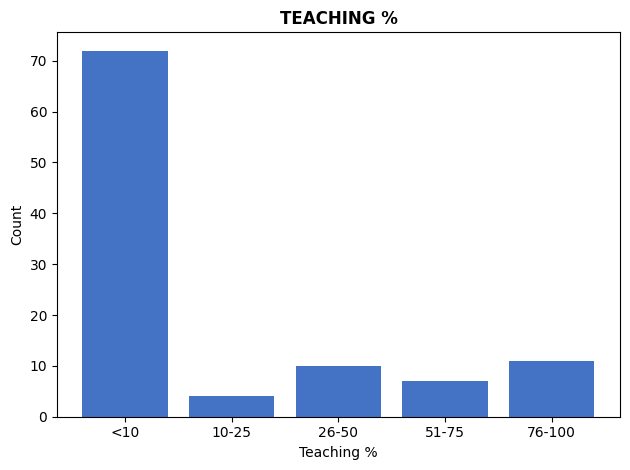

In [10]:
fig, ax = plt.subplots()
ax.bar(counts.index.astype(str), counts.values, color="#4472C4")
ax.set_title("TEACHING %", fontweight="bold")
ax.set_xlabel("Teaching %")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

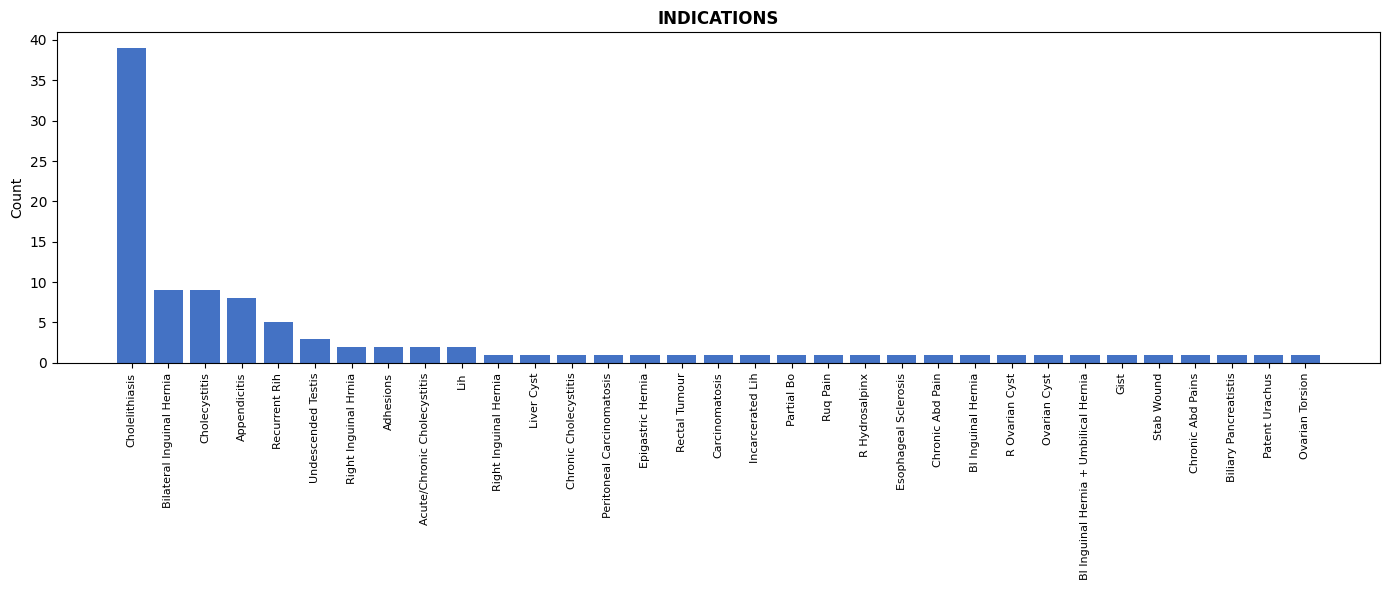

In [11]:
indication_map = {
    "Cholecystits": "Cholecystitis",
    "Lh": "Lih",
    "Rih": "Recurrent Rih",
    "Riqp": "Recurrent Rih",
    "Rlqp": "Recurrent Rih",
    # add more as needed
}

counts_ind = (df["Indication"]
              .str.strip()
              .str.lower()
              .str.title()
              .replace(indication_map)
              .value_counts()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(counts_ind.index, counts_ind.values, color="#4472C4")
ax.set_title("INDICATIONS", fontweight="bold")
ax.set_ylabel("Count")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
df

,Hospital Number,Name,Village of residence,Sex,Age at surgery,Weight (kg),Ward,Previous abdominal surgery (Yes/No),Date of surgery,Type of Surgery,...,Teaching %,Amount of Gas Used (L),Conversion,Reason of conversion,Time of conversion (min. after incisicon),Complication,Complication (Clavien/Dindo),Complication description,Year,Teaching % Group
0,339284,Alex chitandale,malengachanza,MALE,28.0,NaN,SW,No,2022-10-20,AE,...,<10,50,No,NaN,NaN,no,NaN,NaN,2022,<10
1,UNKNOWN_1,Lifinet kapichi,mapiko,FEMALE,57.0,NaN,SW,No,2022-11-17,CHE,...,<10,37,No,NaN,NaN,NaN,NaN,NaN,2022,<10
2,341101,Annie Pheratu,area 23,FEMALE,38.0,NaN,SW,No,2022-11-24,CHE,...,<10,54,No,NaN,NaN,NaN,NaN,NaN,2022,<10
3,345144,chrissy nkanasi,kalolo,FEMALE,54.0,NaN,SW,No,2022-12-28,CHE,...,<10,270,No,NaN,NaN,NaN,NaN,NaN,2022,<10
4,344747,Brown Kapoloma,Kalosa,MALE,62.0,NaN,SW,No,2023-01-26,CHE 1 open prostatectomy,...,<10,242,No,NaN,NaN,No,NaN,NaN,2023,<10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,31248,Asiyatu Allan,dedza,FEMALE,41.0,,SW,No,2025-11-12,"laparoscopic cholecystectomy, chronic cholecys...",...,<10,163,no,,,No,,,2025,<10
100,,Marrium Lori,lilongwe,FEMALE,16.0,,SW,No,2025-11-18,"diagn. lsc. Urachus resection, 16yo. patent ur...",...,60,27,no,,,No,,,2025,51-75
101,31956,Grace Chipole,lilongwe,FEMALE,47.0,,PVT,No,2025-11-19,"laparoscopic cholecystectomy, sympt cholecysto...",...,50,43,no,,,No,,,2025,26-50
102,32499,Fatima Lack,lilongwe,FEMALE,32.0,,SW,No,2025-11-27,"laparoscopic r. adnexectomy, ovarian torsion",...,60,33,no,,,No,,,2025,51-75


In [21]:
import pandas as pd

df_lap = df.copy()
df_lap['Quarter'] = df_lap['Date of surgery'].dt.to_period('Q').astype(str)
df_lap['is_teaching'] = df_lap['Teaching % Group'] != '<10'
df_lap['Teaching Status'] = df_lap['is_teaching'].map({True: 'Teaching', False: 'Non-teaching'})
df_lap['Muscle relaxant used'] = df_lap['Muscle relaxant used'].str.strip().str.lower()

# Fix numeric columns stored as strings
df_lap['Duration (Mins)'] = pd.to_numeric(df_lap['Duration (Mins)'], errors='coerce')
df_lap['Amount of Gas Used (L)'] = pd.to_numeric(df_lap['Amount of Gas Used (L)'], errors='coerce')

# OR if you want to check the numeric 'Teaching %' column directly, convert first:
# df_lap['is_teaching'] = pd.to_numeric(df_lap['Teaching %'], errors='coerce').fillna(0) > 0

# Metric cards
print("total:", len(df_lap))
print("teachingCount:", df_lap['is_teaching'].sum())
print("avgDuration teach:", df_lap[df_lap['is_teaching']]['Duration (Mins)'].mean())
print("avgDuration non-teach:", df_lap[~df_lap['is_teaching']]['Duration (Mins)'].mean())
print("avgGas teach:", df_lap[df_lap['is_teaching']]['Amount of Gas Used (L)'].mean())
print("avgGas non-teach:", df_lap[~df_lap['is_teaching']]['Amount of Gas Used (L)'].mean())

# By teaching group
print(df_lap.groupby('Teaching % Group').size())
print(df_lap.groupby('Teaching % Group')['Duration (Mins)'].mean())
print(df_lap.groupby('Teaching % Group')['Amount of Gas Used (L)'].mean())

# Teaching % per quarter
q = df_lap.groupby('Quarter')['is_teaching'].mean() * 100
print(q)

# Gas per quarter
print(df_lap.groupby('Quarter')['Amount of Gas Used (L)'].mean())

# Muscle relaxants
print(df_lap['Muscle relaxant used'].value_counts())
print(df_lap.groupby(['Year','Muscle relaxant used']).size().unstack(fill_value=0))

total: 104
teachingCount: 32
avgDuration teach: 86.03225806451613
avgDuration non-teach: 98.31884057971014
avgGas teach: 119.74375
avgGas non-teach: 131.34328358208955
Teaching % Group
10-25      4
26-50     10
51-75      7
76-100    11
<10       72
dtype: int64
Teaching % Group
10-25      82.750000
26-50     111.888889
51-75      72.000000
76-100     75.000000
<10        98.318841
Name: Duration (Mins), dtype: float64
Teaching % Group
10-25      86.000000
26-50     184.080000
51-75      89.000000
76-100     93.090909
<10       131.343284
Name: Amount of Gas Used (L), dtype: float64
Quarter
2022Q4     0.000000
2023Q1     0.000000
2023Q2     0.000000
2023Q3    40.000000
2023Q4     0.000000
2024Q1    28.571429
2024Q2    42.857143
2024Q3    33.333333
2024Q4    18.181818
2025Q1    50.000000
2025Q2     0.000000
2025Q3    50.000000
2025Q4    76.923077
Name: is_teaching, dtype: float64
Quarter
2022Q4    102.750000
2023Q1     92.600000
2023Q2     67.000000
2023Q3     74.800000
2023Q4    152.66

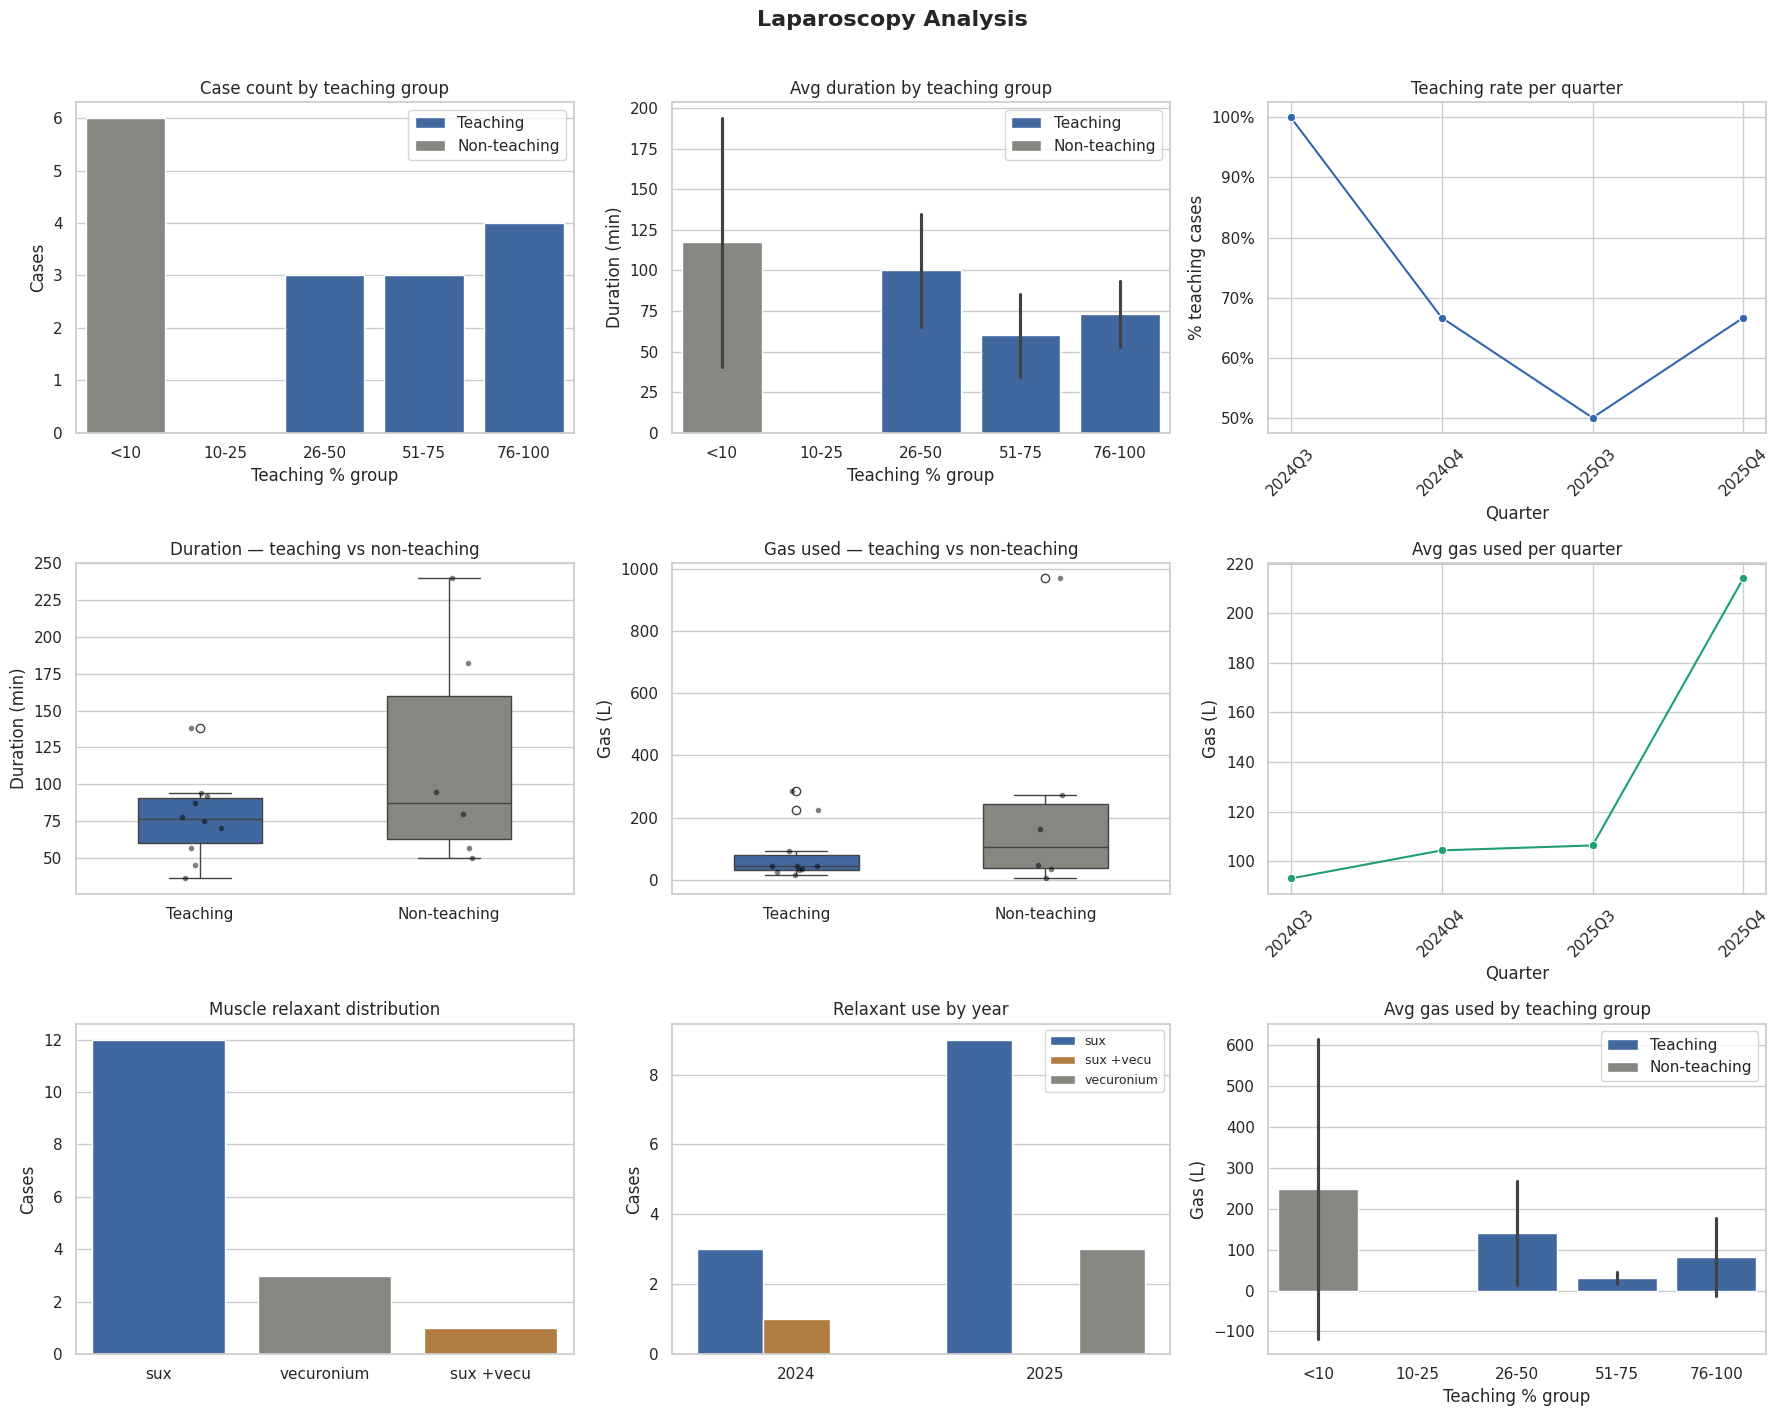

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# ── Setup ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("Laparoscopy Analysis", fontsize=16, fontweight='bold', y=1.01)

GROUP_ORDER = ['<10', '10-25', '26-50', '51-75', '76-100']
BLUE, GRAY, TEAL, AMBER = '#3266ad', '#888780', '#1D9E75', '#c47d2e'

df_lap = df[df['Type of Surgery'].str.contains('laparoscop', case=False, na=False)].copy()
df_lap['Quarter'] = df_lap['Date of surgery'].dt.to_period('Q').astype(str)
df_lap['is_teaching'] = df_lap['Teaching % Group'] != '<10'
df_lap['Teaching Status'] = df_lap['is_teaching'].map({True: 'Teaching', False: 'Non-teaching'})
df_lap['Muscle relaxant used'] = df_lap['Muscle relaxant used'].str.strip().str.lower()

# ── 1. Case count by teaching group ───────────────────────────────────
ax = axes[0, 0]
group_counts = df_lap.groupby(['Teaching % Group', 'Teaching Status']).size().reset_index(name='Count')
sns.barplot(data=group_counts, x='Teaching % Group', y='Count',
            hue='Teaching Status', order=GROUP_ORDER,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY}, ax=ax)
ax.set_title("Case count by teaching group")
ax.set_xlabel("Teaching % group"); ax.set_ylabel("Cases")
ax.legend(title=None)

# ── 2. Duration by teaching group ─────────────────────────────────────
ax = axes[0, 1]
sns.barplot(data=df_lap, x='Teaching % Group', y='Duration (Mins)',
            hue='Teaching Status', order=GROUP_ORDER,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            estimator='mean', errorbar='sd', ax=ax)
ax.set_title("Avg duration by teaching group")
ax.set_xlabel("Teaching % group"); ax.set_ylabel("Duration (min)")
ax.legend(title=None)

# ── 3. Teaching % per quarter ──────────────────────────────────────────
ax = axes[0, 2]
q_teach = df_lap.groupby('Quarter')['is_teaching'].mean().mul(100).reset_index()
q_teach.columns = ['Quarter', 'Teaching %']
sns.lineplot(data=q_teach, x='Quarter', y='Teaching %',
             marker='o', color=BLUE, ax=ax)
ax.set_title("Teaching rate per quarter")
ax.set_ylabel("% teaching cases")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=45)

# ── 4. Duration — teaching vs non-teaching ────────────────────────────
ax = axes[1, 0]
sns.boxplot(data=df_lap, x='Teaching Status', y='Duration (Mins)',
            hue='Teaching Status', legend=False,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            width=0.5, ax=ax)
sns.stripplot(data=df_lap, x='Teaching Status', y='Duration (Mins)',
              color='black', size=4, alpha=0.5, ax=ax)
ax.set_title("Duration — teaching vs non-teaching")
ax.set_xlabel(""); ax.set_ylabel("Duration (min)")

# ── 5. Gas used — teaching vs non-teaching ────────────────────────────
ax = axes[1, 1]
sns.boxplot(data=df_lap, x='Teaching Status', y='Amount of Gas Used (L)',
            hue='Teaching Status', legend=False,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            width=0.5, ax=ax)
sns.stripplot(data=df_lap, x='Teaching Status', y='Amount of Gas Used (L)',
              color='black', size=4, alpha=0.5, ax=ax)
ax.set_title("Gas used — teaching vs non-teaching")
ax.set_xlabel(""); ax.set_ylabel("Gas (L)")


# ── 6. Gas used per quarter ───────────────────────────────────────────
ax = axes[1, 2]
q_gas = df_lap.groupby('Quarter')['Amount of Gas Used (L)'].mean().reset_index()
sns.lineplot(data=q_gas, x='Quarter', y='Amount of Gas Used (L)',
             marker='o', color=TEAL, ax=ax)
ax.set_title("Avg gas used per quarter")
ax.set_ylabel("Gas (L)")
ax.tick_params(axis='x', rotation=45)

# ── 7. Muscle relaxant distribution ──────────────────────────────────
ax = axes[2, 0]
rel_counts = df_lap['Muscle relaxant used'].value_counts().reset_index()
rel_counts.columns = ['Relaxant', 'Count']
colors = [BLUE, GRAY, AMBER, TEAL][:len(rel_counts)]
sns.barplot(data=rel_counts, x='Relaxant', y='Count',
            hue='Relaxant', legend=False,
            palette=dict(zip(rel_counts['Relaxant'], colors)), ax=ax)
ax.set_title("Muscle relaxant distribution")
ax.set_xlabel(""); ax.set_ylabel("Cases")

# ── 8. Relaxant use by year ───────────────────────────────────────────
ax = axes[2, 1]
rel_year = df_lap.groupby(['Year', 'Muscle relaxant used']).size().reset_index(name='Count')
sns.barplot(data=rel_year, x='Year', y='Count',
            hue='Muscle relaxant used',
            palette={'sux': BLUE, 'vecuronium': GRAY, 'sux +vecu': AMBER},
            ax=ax)
ax.set_title("Relaxant use by year")
ax.set_xlabel(""); ax.set_ylabel("Cases")
ax.legend(title=None, fontsize=9)

# ── 9. Gas used by teaching group ────────────────────────────────────
ax = axes[2, 2]
sns.barplot(data=df_lap, x='Teaching % Group', y='Amount of Gas Used (L)',
            hue='Teaching Status', order=GROUP_ORDER,
            palette={'Teaching': BLUE, 'Non-teaching': GRAY},
            estimator='mean', errorbar='sd', ax=ax)
ax.set_title("Avg gas used by teaching group")
ax.set_xlabel("Teaching % group"); ax.set_ylabel("Gas (L)")
ax.legend(title=None)

# ── Final layout ──────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig("laparoscopy_analysis.png", dpi=150, bbox_inches='tight')
plt.show()